<a href="https://colab.research.google.com/github/ashleshashuklaa/Menstrual-Health-Anomaly-Detector/blob/p4%2Fclassical-transformer/newrandom_forest_baseline_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

print("All libraries loaded ✅")

Mounted at /content/drive
All libraries loaded ✅


In [2]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/SheCares/SheCares2 - dataset/menstrual_health_dataset.csv')

# Same 10 features as Transformer
feature_cols = ['age', 'bmi', 'exercise_level', 'diet_quality',
                'cycle_length', 'cramp_score', 'mood_score',
                'flow_intensity', 'sleep_quality', 'stress_score']
SEQ_LEN = 6

# Same patient level split as Transformer
all_clients = df['client_id'].unique()
np.random.seed(42)
np.random.shuffle(all_clients)

n = len(all_clients)
train_clients = set(all_clients[:int(0.60*n)])
test_clients  = set(all_clients[int(0.60*n):int(0.90*n)])
val_clients   = set(all_clients[int(0.90*n):])

print(f"Train patients: {len(train_clients)}")
print(f"Test patients:  {len(test_clients)}")
print(f"Val patients:   {len(val_clients)}")
print(f"Overlap:        {len(train_clients & test_clients & val_clients)}")

# Create sequences
def make_sequences(data, client_set):
    X, y = [], []
    for client in client_set:
        cd = data[data['client_id']==client].sort_values('cycle_number').reset_index(drop=True)
        for i in range(SEQ_LEN, len(cd)):
            X.append(cd[feature_cols].iloc[i-SEQ_LEN:i].values)
            y.append(cd['anomaly'].iloc[i])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(df, train_clients)
X_test,  y_test  = make_sequences(df, test_clients)
X_val,   y_val   = make_sequences(df, val_clients)

# Normalize — fit on train only
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train.reshape(-1,10)).reshape(X_train.shape)
X_test_s  = scaler.transform(X_test.reshape(-1,10)).reshape(X_test.shape)
X_val_s   = scaler.transform(X_val.reshape(-1,10)).reshape(X_val.shape)

# Add same noise as Transformer
np.random.seed(42)
X_train_n = np.clip(X_train_s + np.random.normal(0,0.2,X_train_s.shape), 0, 1)
X_test_n  = np.clip(X_test_s  + np.random.normal(0,0.2,X_test_s.shape),  0, 1)
X_val_n   = np.clip(X_val_s   + np.random.normal(0,0.2,X_val_s.shape),   0, 1)

# Flatten for Random Forest (needs 2D input)
X_train_flat = X_train_n.reshape(X_train_n.shape[0], -1)  # (2006, 60)
X_test_flat  = X_test_n.reshape(X_test_n.shape[0], -1)    # (952, 60)
X_val_flat   = X_val_n.reshape(X_val_n.shape[0], -1)      # (357, 60)

print(f"\nTrain: {X_train_flat.shape} | Anomaly: {y_train.mean():.3f}")
print(f"Test:  {X_test_flat.shape}  | Anomaly: {y_test.mean():.3f}")
print(f"Val:   {X_val_flat.shape}   | Anomaly: {y_val.mean():.3f}")

Train patients: 300
Test patients:  150
Val patients:   50
Overlap:        0

Train: (2006, 60) | Anomaly: 0.310
Test:  (952, 60)  | Anomaly: 0.243
Val:   (357, 60)   | Anomaly: 0.261


In [3]:
# Class weights
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {0: cw[0], 1: cw[1]}
print("Class weights:", cw_dict)

# Train Random Forest
print("\nTraining Random Forest...")
start = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_flat, y_train)
elapsed = time.time() - start
print(f"Training done in {elapsed:.1f} seconds ✅")

# Evaluate
y_probs = rf.predict_proba(X_test_flat)[:, 1]
y_preds = (y_probs >= 0.5).astype(int)

accuracy = (y_preds == y_test).mean()
precision = precision_score(y_test, y_preds)
recall = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)
auc = roc_auc_score(y_test, y_probs)
ap = average_precision_score(y_test, y_probs)

print("\n" + "=" * 55)
print("  RANDOM FOREST — TEST RESULTS")
print("  Patient Split | Noise σ=0.2 | No Leakage")
print("=" * 55)
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"AUC-ROC         : {auc:.4f}")
print(f"Avg Precision   : {ap:.4f}")
print(f"Train time      : {elapsed:.1f} sec")
print("=" * 55)
print()
print(classification_report(y_test, y_preds,
      target_names=['Normal', 'Anomaly']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_preds))

Class weights: {0: np.float64(0.7241877256317689), 1: np.float64(1.6151368760064413)}

Training Random Forest...
Training done in 3.2 seconds ✅

  RANDOM FOREST — TEST RESULTS
  Patient Split | Noise σ=0.2 | No Leakage
Accuracy        : 0.9433
Precision       : 0.9041
Recall          : 0.8571
F1 Score        : 0.8800
AUC-ROC         : 0.9750
Avg Precision   : 0.9424
Train time      : 3.2 sec

              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       721
     Anomaly       0.90      0.86      0.88       231

    accuracy                           0.94       952
   macro avg       0.93      0.91      0.92       952
weighted avg       0.94      0.94      0.94       952

Confusion Matrix:
[[700  21]
 [ 33 198]]


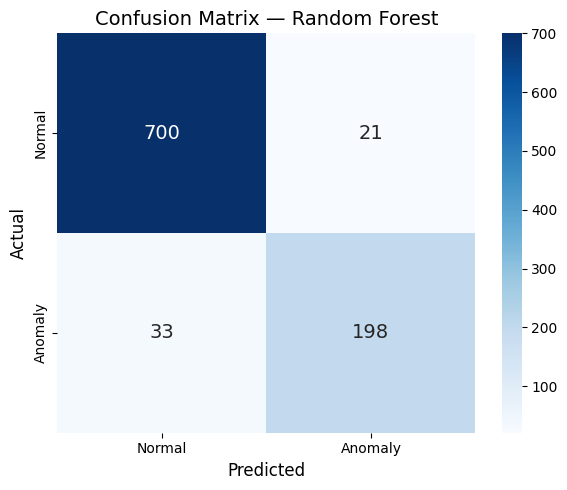

Figure 1 saved ✅


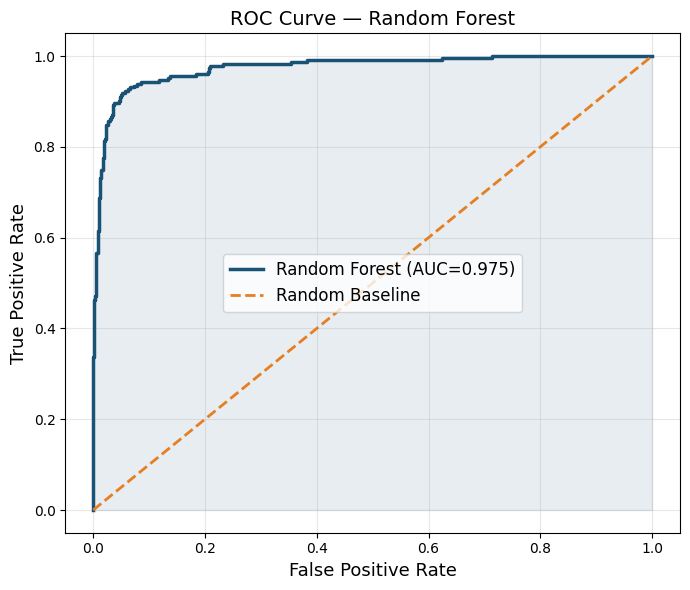

Figure 2 saved ✅


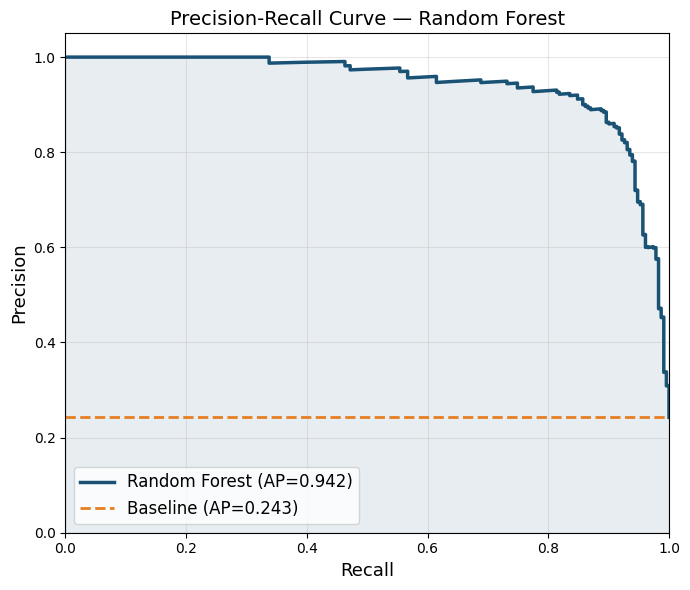

Figure 3 saved ✅


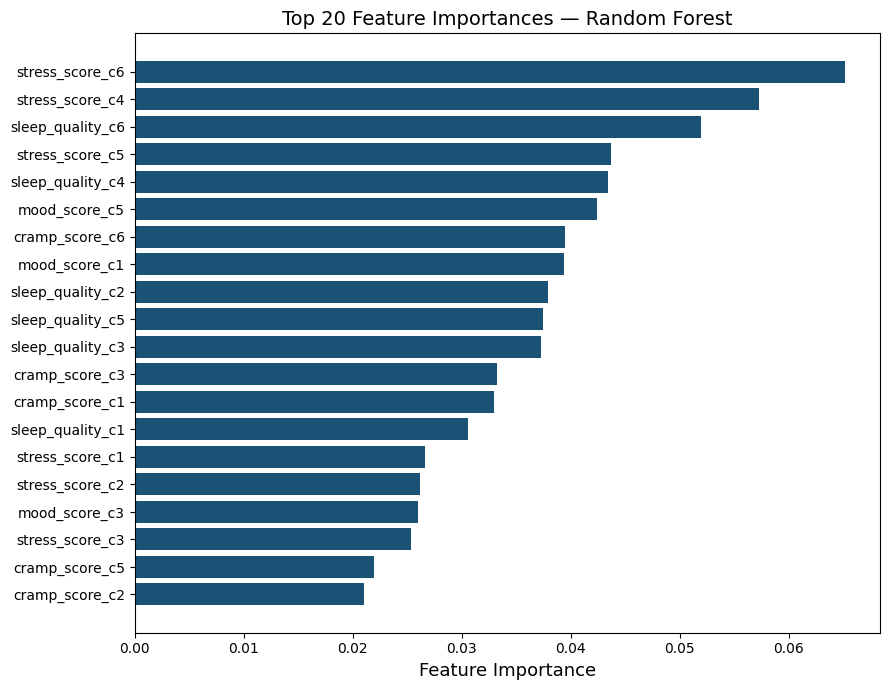

Figure 4 saved ✅

All 4 figures saved to Drive!


In [4]:
figures_path = '/content/drive/MyDrive/SheCares/figures /'

# Figure 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            annot_kws={'size': 14}, ax=ax)
ax.set_title('Confusion Matrix — Random Forest', fontsize=14)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig(figures_path + 'new_random_forest_confusion_matrix.png', dpi=150)
plt.show()
print("Figure 1 saved ✅")

# Figure 2 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
fig2, ax2 = plt.subplots(figsize=(7, 6))
ax2.plot(fpr, tpr, color='#1a5276', linewidth=2.5,
         label=f'Random Forest (AUC={auc:.3f})')
ax2.plot([0,1],[0,1],'--', color='#E67E22',
         linewidth=2, label='Random Baseline')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#1a5276')
ax2.set_xlabel('False Positive Rate', fontsize=13)
ax2.set_ylabel('True Positive Rate', fontsize=13)
ax2.set_title('ROC Curve — Random Forest', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_path + 'new_random_forest_roc_curve.png', dpi=150)
plt.show()
print("Figure 2 saved ✅")

# Figure 3 — Precision Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_probs)
baseline = y_test.sum() / len(y_test)
fig3, ax3 = plt.subplots(figsize=(7, 6))
ax3.plot(rec_curve, prec_curve, color='#1a5276', linewidth=2.5,
         label=f'Random Forest (AP={ap:.3f})')
ax3.axhline(y=baseline, color='#E67E22', linewidth=2,
            linestyle='--', label=f'Baseline (AP={baseline:.3f})')
ax3.fill_between(rec_curve, prec_curve, alpha=0.1, color='#1a5276')
ax3.set_xlabel('Recall', fontsize=13)
ax3.set_ylabel('Precision', fontsize=13)
ax3.set_title('Precision-Recall Curve — Random Forest', fontsize=14)
ax3.legend(fontsize=12)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1.05])
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_path + 'new_random_forest_precision_recall.png', dpi=150)
plt.show()
print("Figure 3 saved ✅")

# Figure 4 — Feature Importance
feature_names_flat = []
for t in range(1, 7):
    for f in feature_cols:
        feature_names_flat.append(f'{f}_c{t}')

importances = rf.feature_importances_
top_idx = np.argsort(importances)[-20:]  # top 20

fig4, ax4 = plt.subplots(figsize=(9, 7))
ax4.barh([feature_names_flat[i] for i in top_idx],
         importances[top_idx],
         color='#1a5276')
ax4.set_xlabel('Feature Importance', fontsize=13)
ax4.set_title('Top 20 Feature Importances — Random Forest', fontsize=14)
plt.tight_layout()
plt.savefig(figures_path + 'new_random_forest_feature_importance.png', dpi=150)
plt.show()
print("Figure 4 saved ✅")

print("\nAll 4 figures saved to Drive!")

In [5]:
# Save model
model_path = '/content/drive/MyDrive/SheCares/models saved_models/'
joblib.dump(rf, model_path + 'new_random_forest_model.pkl')
print("Model saved ✅")

# Save scaler
data_path = '/content/drive/MyDrive/SheCares/datasets cleaned/'
joblib.dump(scaler, data_path + 'new_random_forest_scaler.pkl')
print("Scaler saved ✅")

# Save results CSV
results_path = '/content/drive/MyDrive/SheCares/models results/'
results = pd.DataFrame([{
    'model': 'Random_Forest',
    'accuracy': round(accuracy, 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1': round(f1, 4),
    'auc_roc': round(auc, 4),
    'avg_precision': round(ap, 4),
    'train_time_sec': round(elapsed, 2),
    'n_estimators': 200,
    'features': 60,
    'sequence_length': 6,
    'noise_sigma': 0.2,
    'data_leakage': 'None',
    'split_method': 'Patient-level 60-30-10',
    'overfitting': 'None'
}])

results.to_csv(results_path + 'new_random_forest_results.csv', index=False)
print("Results CSV saved ✅")
print()
print(results.to_string(index=False))

Model saved ✅
Scaler saved ✅
Results CSV saved ✅

        model  accuracy  precision  recall   f1  auc_roc  avg_precision  train_time_sec  n_estimators  features  sequence_length  noise_sigma data_leakage           split_method overfitting
Random_Forest    0.9433     0.9041  0.8571 0.88    0.975         0.9424            3.23           200        60                6          0.2         None Patient-level 60-30-10        None
